#Model

ok, potrzebuję zrobić analizę daty. Tutaj trochę notatek:

1. Po co wybierać pomiędzy CNN i SNN, kiedy można zrobić od razu SCNN? XDD

Dobra, bo ogólnie chcę zrobić mały eksperymrnt z architekturą sieci neuronowej. Bo zobaczyłam taki układ w tutoriale do snntorch-a. Chcę potem porównać z samym snn.

2.


In [1]:
!pip install tonic
!pip install snntorch

In [2]:
import torchvision
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import spikeplot as splt
from torch import nn
import tonic
from torch.utils.data import DataLoader, random_split
import tonic.transforms as transforms
from tonic import DiskCachedDataset
import random

In [3]:
#cuda setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
#seed setup
SEED = 42
random.seed(SEED) #dla każdej biblioteki ustawiamy seed'a osobno
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


##setup modelu


In [4]:
setup = {
    "beta" : 0.9,
    "spike_grad" : surrogate.fast_sigmoid(slope=5), #f-ja aktywacji
    "img_size" : (128, 128),
    "data_root" : "./cache/ncaltech101",
    "lr" : 2e-3,
    "batch_size" : 67,
    "num_workers" : 2,
    "epochs" : 15
}

##datawrapper

In [5]:
#klasa dla augmentacji. Tak będzie lepasza randomowość
class DataWrapper(torch.utils.data.Dataset):

    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      data, target = self.dataset[idx]

      if self.transform:
        data = self.transform(data)
        return data, target

      return data, target

##transformacja + adaptacja danych do odpowiedniego formatu + augmentacja

In [6]:
sensor_size = (240, 180, 2)

# Define a custom transform to ensure empty event arrays retain their structured dtype
class EnsureStructuredEmptyEvents(object):
    def __init__(self, expected_dtype):
        self.expected_dtype = expected_dtype

    def __call__(self, events):
        if events.size == 0 and events.dtype.names is None:
            # If it's an empty, unstructured array, return an empty structured array
            return np.empty(0, dtype=self.expected_dtype)
        return events

# Load a single sample from the raw dataset to infer the original event dtype
# This temporary dataset is only for dtype inference and will not be used for training/testing.
raw_dataset_for_dtype = tonic.datasets.NCALTECH101(save_to='./data', transform=None)
first_events, _ = raw_dataset_for_dtype[0]
original_event_dtype = first_events.dtype

train_transform = transforms.Compose([
    transforms.Downsample(sensor_size=sensor_size, target_size=setup["img_size"]),
    transforms.DropEvent(p=0.1),
    transforms.RandomFlipPolarity(),
    EnsureStructuredEmptyEvents(original_event_dtype), # Insert custom transform here
    transforms.TimeJitter(std=0.005),
    transforms.ToFrame(sensor_size=(setup["img_size"][0], setup["img_size"][1], 2), n_time_bins=20),
    lambda x: torch.from_numpy(x).float()
])

#downloading dataset
# NOTE: train_transform is applied here when data is loaded and cached.
dataset = tonic.datasets.NCALTECH101(save_to='./data', transform=train_transform)
cached_dataset = DiskCachedDataset(dataset, cache_path='./cache/ncaltech101')
all_loader = DataLoader(cached_dataset, batch_size=16, shuffle=True)

#dividing dataset into training and test(I decided to not add evaluation part)
train_size = int(0.8 * len(cached_dataset))
test_size = len(cached_dataset) - train_size

train_dataset, test_dataset = random_split(cached_dataset, [train_size, test_size])

# The DataWrapper should NOT re-apply transforms if cached_dataset already provides transformed data.
# Setting transform=None for DataWrapper to avoid double application.
train_dataset = DataWrapper(train_dataset, transform=None)
test_dataset = DataWrapper(test_dataset, transform=None)

train_loader = DataLoader(train_dataset, batch_size=setup["batch_size"], shuffle=True, num_workers=setup["num_workers"])
test_loader = DataLoader(test_dataset, batch_size=setup["batch_size"], shuffle=False, num_workers=setup["num_workers"])


  0%|          | 0/3989375649 [00:00<?, ?it/s]

Extracting ./data/NCALTECH101/N-Caltech101-archive.zip to ./data/NCALTECH101


##klasa modelu + dodatkowe kroki




In [7]:


import os # Import os module to handle file paths

class SCNNetwork(nn.Module):
  def __init__(self, inp_ch = 2, outp_ch = 101, kern_s = 3, strd = 1, pd = 1, bs = False, bet = setup["beta"]):
    super().__init__()
    self.conv1 = nn.Conv2d(inp_ch, inp_ch*8, kernel_size = kern_s, stride = strd, padding = pd, bias = bs)
    self.conv2 = nn.Conv2d(inp_ch*8, inp_ch*16, kernel_size = kern_s, stride = strd, padding = pd)
    self.flatten = nn.Flatten()
    self.linear = nn.Linear(inp_ch*16*32*32, 101)
    self.leaky1 = snn.Leaky(beta=bet, spike_grad=setup["spike_grad"])
    self.leaky2 = snn.Leaky(beta=bet, spike_grad=setup["spike_grad"], output=True)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout = nn.Dropout(p=0.5) # Add dropout layer with 50% probability

  def forward(self, x):
    mem1 = self.leaky1.init_leaky()
    mem2 = self.leaky1.init_leaky()
    mem3 = self.leaky2.init_leaky()

    num_steps = x.shape[1]

    spk3_rec = []
    mem3_rec = [] # Dodajemy listę na rejestrację potencjału

    for step in range(num_steps):
            x_step = x[:, step, :, :, :]

            #layer 1
            cur1 = self.conv1(x_step)
            cur1 = self.pool(cur1)
            spk1, mem1 = self.leaky1(cur1, mem1)

            #layer 2
            cur2 = self.conv2(spk1)
            cur2 = self.pool(cur2)
            spk2, mem2 = self.leaky1(cur2, mem2)

            #output
            out = self.flatten(spk2)
            out = self.linear(out)
            spk3, mem3 = self.leaky2(out, mem3)

            spk3_rec.append(spk3)
            mem3_rec.append(mem3)

    return torch.stack(spk3_rec, dim=0), torch.stack(mem3_rec, dim=0)

model = SCNNetwork().to(device) # Move model to device

# Dynamically get class names from the dataset directory structure
dataset_root_path = os.path.join('./data', 'NCALTECH101', 'Caltech101')
class_names = sorted([d for d in os.listdir(dataset_root_path) if os.path.isdir(os.path.join(dataset_root_path, d))])
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

#possibly useless, I need to test without it.
for data, raw_targets in train_loader:

    data = data.to(device) # Move data to device
    # Convert byte string targets to integer tensor targets
    target_indices = [class_to_idx[t.decode('utf-8')] for t in raw_targets]
    targets = torch.tensor(target_indices, dtype=torch.long).to(device)

    output_spikes, output_mem = model(data) # Unpack both spikes and membrane potentials

    # Calculate loss
    spike_counts = output_spikes.sum(dim=0)  # Shape: [16, 101]
    loss = nn.CrossEntropyLoss()(spike_counts, targets)
    break




old_sketch = '''def net(inp_ch = 2, outp_ch = 101, kern_s = 3, strd = 1, pd = 1, bs = False, bet = setup[beta]):
  net = nn.Sequential(nn.Conv2d(inp_ch, inp_ch*8, kernel_size = kern_s, stride = strd, padding = padding, bias = bs),
                      nn.MaxPool2d(kernel_size=2, stride=2),
                      snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
                      nn.Conv2d(inp_ch*8, inp_ch*16, kernel_size = kern_s, stride = strd, padding = pd),
                      nn.MaxPool2d(kernel_size=2, stride=2),
                      snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
                      nn.Flatten(),
                      nn.Linear(inp_ch*16*8*8, 101),
                      snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output=True)
                      ).to(device)
  return net''' #zdecydowałam jednak zrobić to przez zmienne dla większej wariatywności i łatwiejszego odczytywania

##training loop

In [8]:
from sklearn.metrics import f1_score, jaccard_score # Added imports

#training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, betas=(0.9, 0.999))
loss_fn = SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2)

#num_epochs = 1 # was for testing purposes
num_steps = 25  # run for 25 time steps

loss_hist = [] # record loss over iterations
acc_hist = [] # record accuracy over iterations

#dla wizualki
train_loss_hist = []
test_loss_hist = []
test_acc_hist = []

# training loop
for epoch in range(setup["epochs"]):
    for i, (data, raw_targets) in enumerate(iter(train_loader)):
        data = data.to(device)
        # Convert byte string targets to integer tensor targets
        target_indices = [class_to_idx[t.decode('utf-8')] for t in raw_targets]
        targets = torch.tensor(target_indices, dtype=torch.long).to(device)

        model.train()
        spk_rec, mem_rec = model(data) # forward-pass, now correctly unpacking two values
        loss_val = loss_fn(spk_rec, targets) # loss calculation
        optimizer.zero_grad() # null gradients
        loss_val.backward() # calculate gradients
        optimizer.step() # update weights
        loss_hist.append(loss_val.item()) # store loss

        # print every 25 iterations
        if i % 25 == 0:
          model.eval()
          print(f"Epoch {epoch}, Iteration {i} \nTrain Loss: {loss_val.item():.2f}")

    model.eval()
    test_loss_total = 0
    test_acc_total = 0
    all_preds_epoch = [] # To collect predictions for this epoch's test metrics
    all_targets_epoch = [] # To collect true labels for this epoch's test metrics

    with torch.no_grad(): # Wyłączenie śledzenia gradientów dla oszczędności pamięci i czasu
        for data, raw_targets in test_loader:
            data = data.to(device)
            target_indices = [class_to_idx[t.decode('utf-8')] for t in raw_targets]
            targets = torch.tensor(target_indices, dtype=torch.long).to(device)

            spk_rec, mem_rec = model(data)

            loss_val = loss_fn(spk_rec, targets)
            test_loss_total += loss_val.item()

            # Sum spikes over time steps to get total spikes per class
            total_spikes_per_class = spk_rec.sum(dim=0) # [batch_size, num_classes]
            predicted_class_indices = torch.argmax(total_spikes_per_class, dim=1)

            all_preds_epoch.extend(predicted_class_indices.cpu().numpy())
            all_targets_epoch.extend(targets.cpu().numpy())

            test_acc_total += SF.accuracy_rate(spk_rec, targets)

    # Obliczenie średnich wartości dla całej epoki
    avg_test_loss = test_loss_total / len(test_loader)
    avg_test_acc = test_acc_total / len(test_loader)

    # Calculate F1-score and Mean IoU (Jaccard Index) for the current epoch
    # Using 'macro' average for multi-class classification to treat all classes equally
    f1 = f1_score(all_targets_epoch, all_preds_epoch, average='macro', zero_division=0)
    iou = jaccard_score(all_targets_epoch, all_preds_epoch, average='macro', zero_division=0)

    test_loss_hist.append(avg_test_loss)
    test_acc_hist.append(avg_test_acc)

    print(f"Test Loss: {avg_test_loss:.2f}")
    print(f"Test Accuracy: {avg_test_acc:.2f}")
    print(f"Test F1-Score (macro): {f1:.2f}")
    print(f"Test Mean IoU (macro): {iou:.2f}")

Epoch 0, Iteration 0 
Train Loss: 0.90
Epoch 0, Iteration 25 
Train Loss: 0.92
Epoch 0, Iteration 50 
Train Loss: 0.21
Epoch 0, Iteration 75 
Train Loss: 0.14
Epoch 0, Iteration 100 
Train Loss: 0.08
Test Loss: 0.09
Test Accuracy: 0.35
Test F1-Score (macro): 0.11
Test Mean IoU (macro): 0.07
Epoch 1, Iteration 0 
Train Loss: 0.08
Epoch 1, Iteration 25 
Train Loss: 0.07
Epoch 1, Iteration 50 
Train Loss: 0.07
Epoch 1, Iteration 75 
Train Loss: 0.06
Epoch 1, Iteration 100 
Train Loss: 0.07
Test Loss: 0.08
Test Accuracy: 0.40
Test F1-Score (macro): 0.16
Test Mean IoU (macro): 0.11
Epoch 2, Iteration 0 
Train Loss: 0.05
Epoch 2, Iteration 25 
Train Loss: 0.05
Epoch 2, Iteration 50 
Train Loss: 0.05
Epoch 2, Iteration 75 
Train Loss: 0.06
Epoch 2, Iteration 100 
Train Loss: 0.06
Test Loss: 0.08
Test Accuracy: 0.41
Test F1-Score (macro): 0.19
Test Mean IoU (macro): 0.13
Epoch 3, Iteration 0 
Train Loss: 0.04
Epoch 3, Iteration 25 
Train Loss: 0.04
Epoch 3, Iteration 50 
Train Loss: 0.04
Epoch

#WIZUALIZACJA

In [13]:
import matplotlib.pyplot as plt
from IPython.display import HTML
import snntorch.spikeplot as splt

# Przełączenie modelu w tryb ewaluacji i pobranie pojedynczego batcha
model.eval()
with torch.no_grad():
    data, raw_targets = next(iter(test_loader))
    data = data.to(device)
    target_indices = [class_to_idx[t.decode("utf-8")] for t in raw_targets]
    targets = torch.tensor(target_indices, dtype=torch.long).to(device)

    # Przejście w przód przez model
    # output_spikes: [num_steps, batch_size, 101]
    # output_mem:    [num_steps, batch_size, 101]
    output_spikes, output_mem = model(data)

# Wybór pojedynczej próbki z batcha do wizualizacji (np. indeks 0)
sample_idx = 0
spk_sample = output_spikes[:, sample_idx, :].cpu()  # Kształt: [num_steps, 101]
mem_sample = output_mem[:, sample_idx, :].cpu()  # Kształt: [num_steps, 101]
target_sample = targets[sample_idx].item()

In [14]:
# Assuming spk_sample (torch.Tensor, shape [num_steps, num_classes]),
# target_sample (int), and class_names (list of strings) are defined
# from previous cells, specifically 8mfdayGBm8h9 and c71j9W3NGVKy.

# Calculate total spikes for each class
total_spikes_per_class = spk_sample.sum(dim=0) # Shape: [num_classes]

# Get predicted class
predicted_idx = torch.argmax(total_spikes_per_class).item()
predicted_label = class_names[predicted_idx]

# Get true label
true_label = class_names[target_sample]

# Determine conclusion
is_correct = (predicted_idx == target_sample)

# Get spike count for the predicted class
# Using .item() to get a standard Python number from a single-element tensor
spikes_count = total_spikes_per_class[predicted_idx].item()

print(f"Predicted: {predicted_label}")
print(f"True label: {true_label}")
print(f"Conclusion: {is_correct}")
print(f"Spikes: {spikes_count}")

Predicted: brain
True label: butterfly
Conclusion: False
Spikes: 6.0


Generating visualizations...


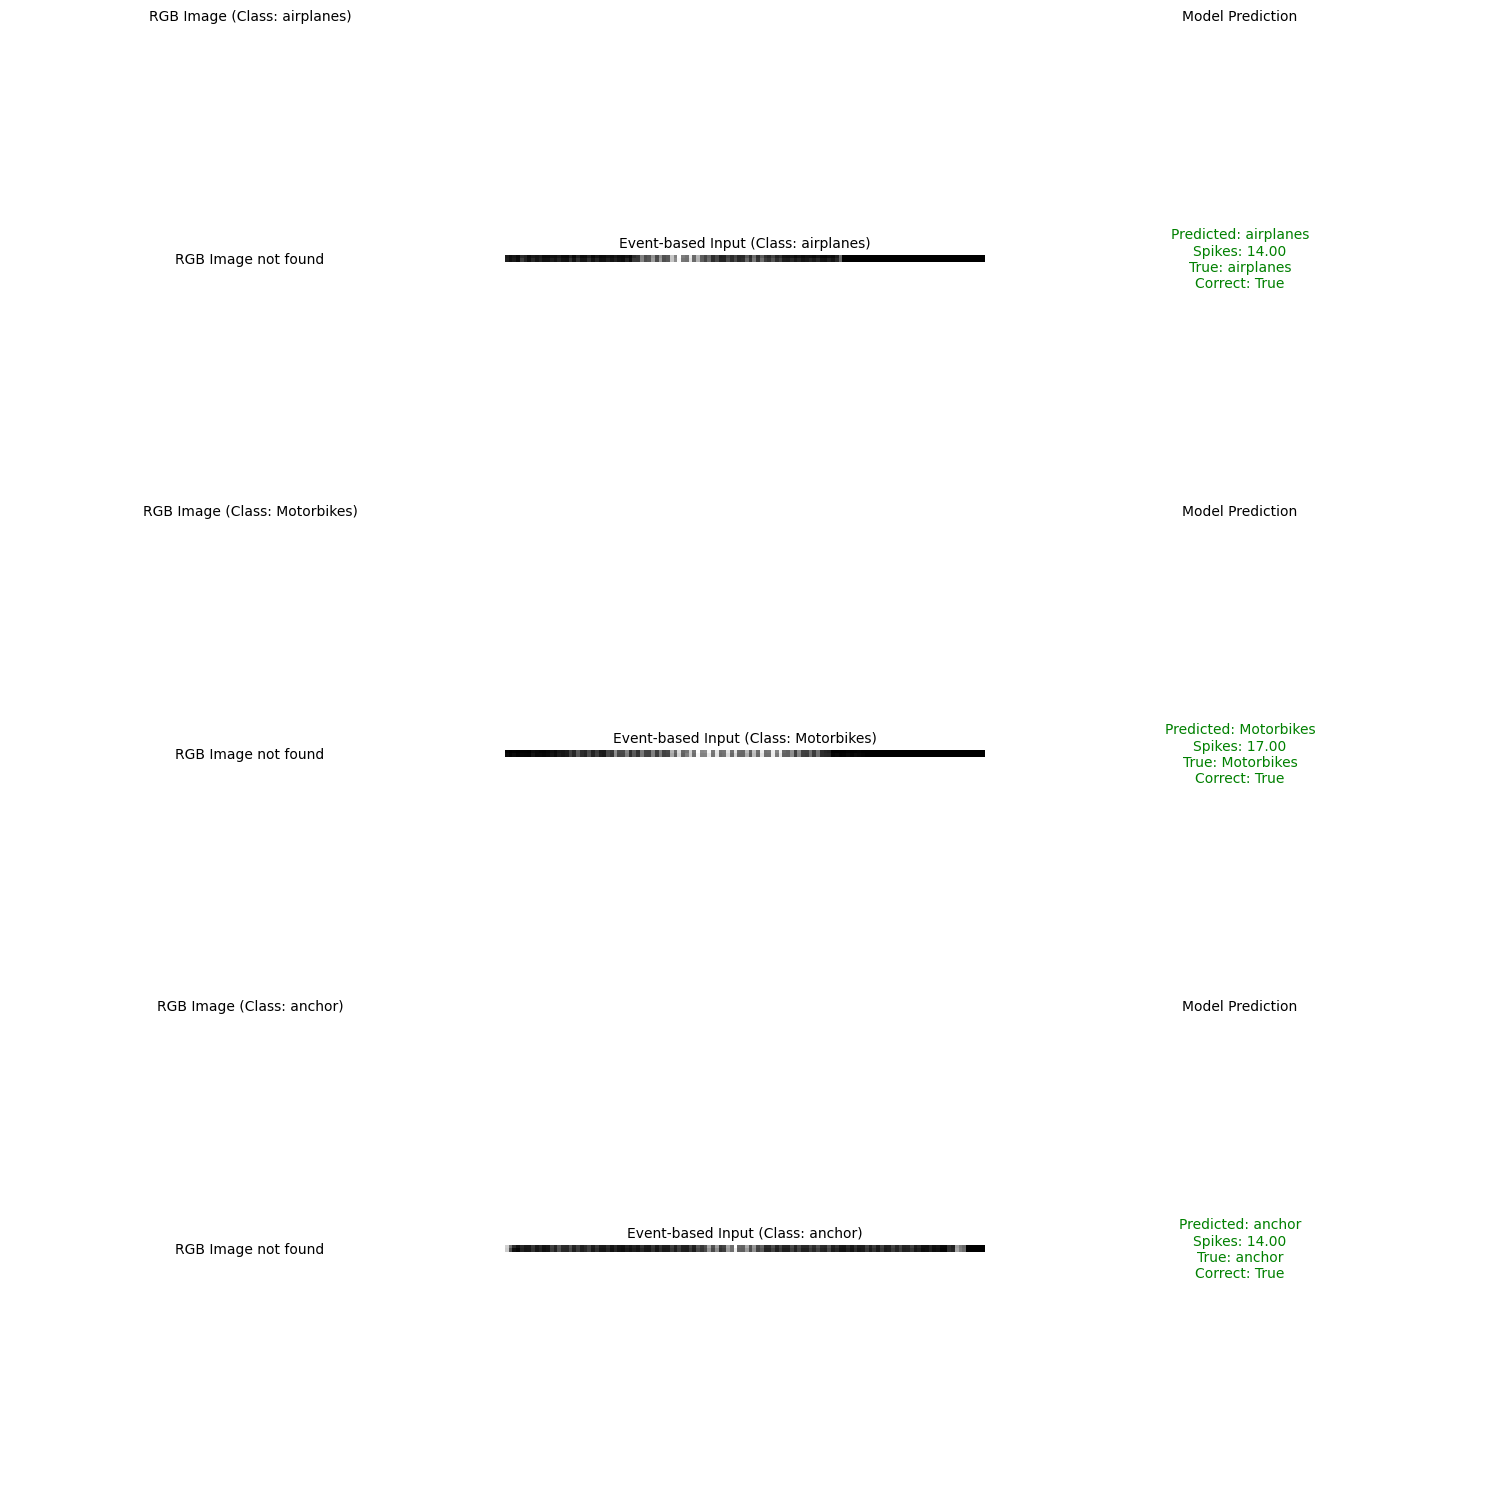

In [15]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import os

# Ensure the model is in evaluation mode
model.eval()

# Function to get an original RGB image for a given class name
def get_random_rgb_image_for_class(class_name, dataset_root):
    class_path = os.path.join(dataset_root, class_name)
    if os.path.isdir(class_path):
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if image_files:
            random_image_path = os.path.join(class_path, random.choice(image_files))
            try:
                img = Image.open(random_image_path).convert('RGB')
                return img
            except Exception as e:
                print(f"Error loading image {random_image_path}: {e}")
    return None

def visualize_model_comparison(model, train_loader, class_to_idx, class_names, dataset_root_path, device, img_size, num_comparisons=3):
    model.eval() # Ensure model is in evaluation mode
    fig, axes = plt.subplots(num_comparisons, 3, figsize=(15, 5 * num_comparisons))

    # Handle single comparison case for consistent indexing
    if num_comparisons == 1:
        axes = axes.reshape(1, -1)

    # Use an iterator for train_loader to get distinct samples for each comparison
    data_iter = iter(train_loader)

    print("Generating visualizations...")

    for i in range(num_comparisons):
        try:
            data_batch, raw_targets_batch = next(data_iter)
        except StopIteration:
            print("Not enough samples in train_loader for the requested number of comparisons.")
            break

        # Pick a random sample from the batch
        sample_idx = random.randint(0, data_batch.shape[0] - 1)
        data_sample = data_batch[sample_idx].unsqueeze(0).to(device) # Get one sample and add batch dim
        raw_target = raw_targets_batch[sample_idx]
        target_class_name = raw_target.decode('utf-8')
        target_idx = class_to_idx[target_class_name]

        # --- Column 1: Original RGB Image ---
        rgb_img = get_random_rgb_image_for_class(target_class_name, dataset_root_path)
        if rgb_img:
            # Resize RGB image to match the event-based input size
            rgb_img_resized = rgb_img.resize(img_size)
            axes[i, 0].imshow(rgb_img_resized)
            axes[i, 0].set_title(f"RGB Image (Class: {target_class_name})", fontsize=10)
            axes[i, 0].axis('off')
        else:
            axes[i, 0].text(0.5, 0.5, "RGB Image not found", ha='center', va='center', transform=axes[i, 0].transAxes, fontsize=10)
            axes[i, 0].set_title(f"RGB Image (Class: {target_class_name})", fontsize=10)
            axes[i, 0].axis('off')

        # --- Column 2: Event-based representation (summed frame) ---
        # data_sample has shape [1 (batch), num_steps, H, W, C]
        # Sum over num_steps and channels to get a single grayscale image
        event_frame = data_sample.squeeze(0).cpu().sum(dim=0).sum(dim=-1).numpy() # sum over time and channels
        # Normalize for display to [0,1]
        if event_frame.max() > event_frame.min():
            event_frame = (event_frame - event_frame.min()) / (event_frame.max() - event_frame.min())
        else:
            event_frame = np.zeros_like(event_frame) # Handle case where all values are the same (e.g., no events)

        axes[i, 1].imshow(event_frame, cmap='gray')
        axes[i, 1].set_title(f"Event-based Input (Class: {target_class_name})", fontsize=10)
        axes[i, 1].axis('off')

        # --- Column 3: Model Output Prediction ---
        with torch.no_grad():
            output_spikes, _ = model(data_sample) # [num_steps, 1 (batch), num_classes]

        # Sum spikes over time steps to get total spikes per class
        total_spikes_per_class = output_spikes.sum(dim=0).squeeze(0) # [num_classes]
        predicted_class_idx = torch.argmax(total_spikes_per_class).item()
        predicted_class_name = class_names[predicted_class_idx]

        is_correct = (predicted_class_idx == target_idx)
        prediction_color = 'green' if is_correct else 'red'

        # Determine the confidence (e.g., spike count for predicted class)
        predicted_spike_count = total_spikes_per_class[predicted_class_idx].item()

        prediction_text = f"Predicted: {predicted_class_name}\n" \
                          f"Spikes: {predicted_spike_count:.2f}\n" \
                          f"True: {target_class_name}\n" \
                          f"Correct: {is_correct}"

        axes[i, 2].text(0.5, 0.5, prediction_text, ha='center', va='center', wrap=True,
                       transform=axes[i, 2].transAxes, fontsize=10, color=prediction_color)
        axes[i, 2].set_title("Model Prediction", fontsize=10)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function with global variables
visualize_model_comparison(model, train_loader, class_to_idx, class_names, dataset_root_path, device, setup["img_size"], num_comparisons=3)

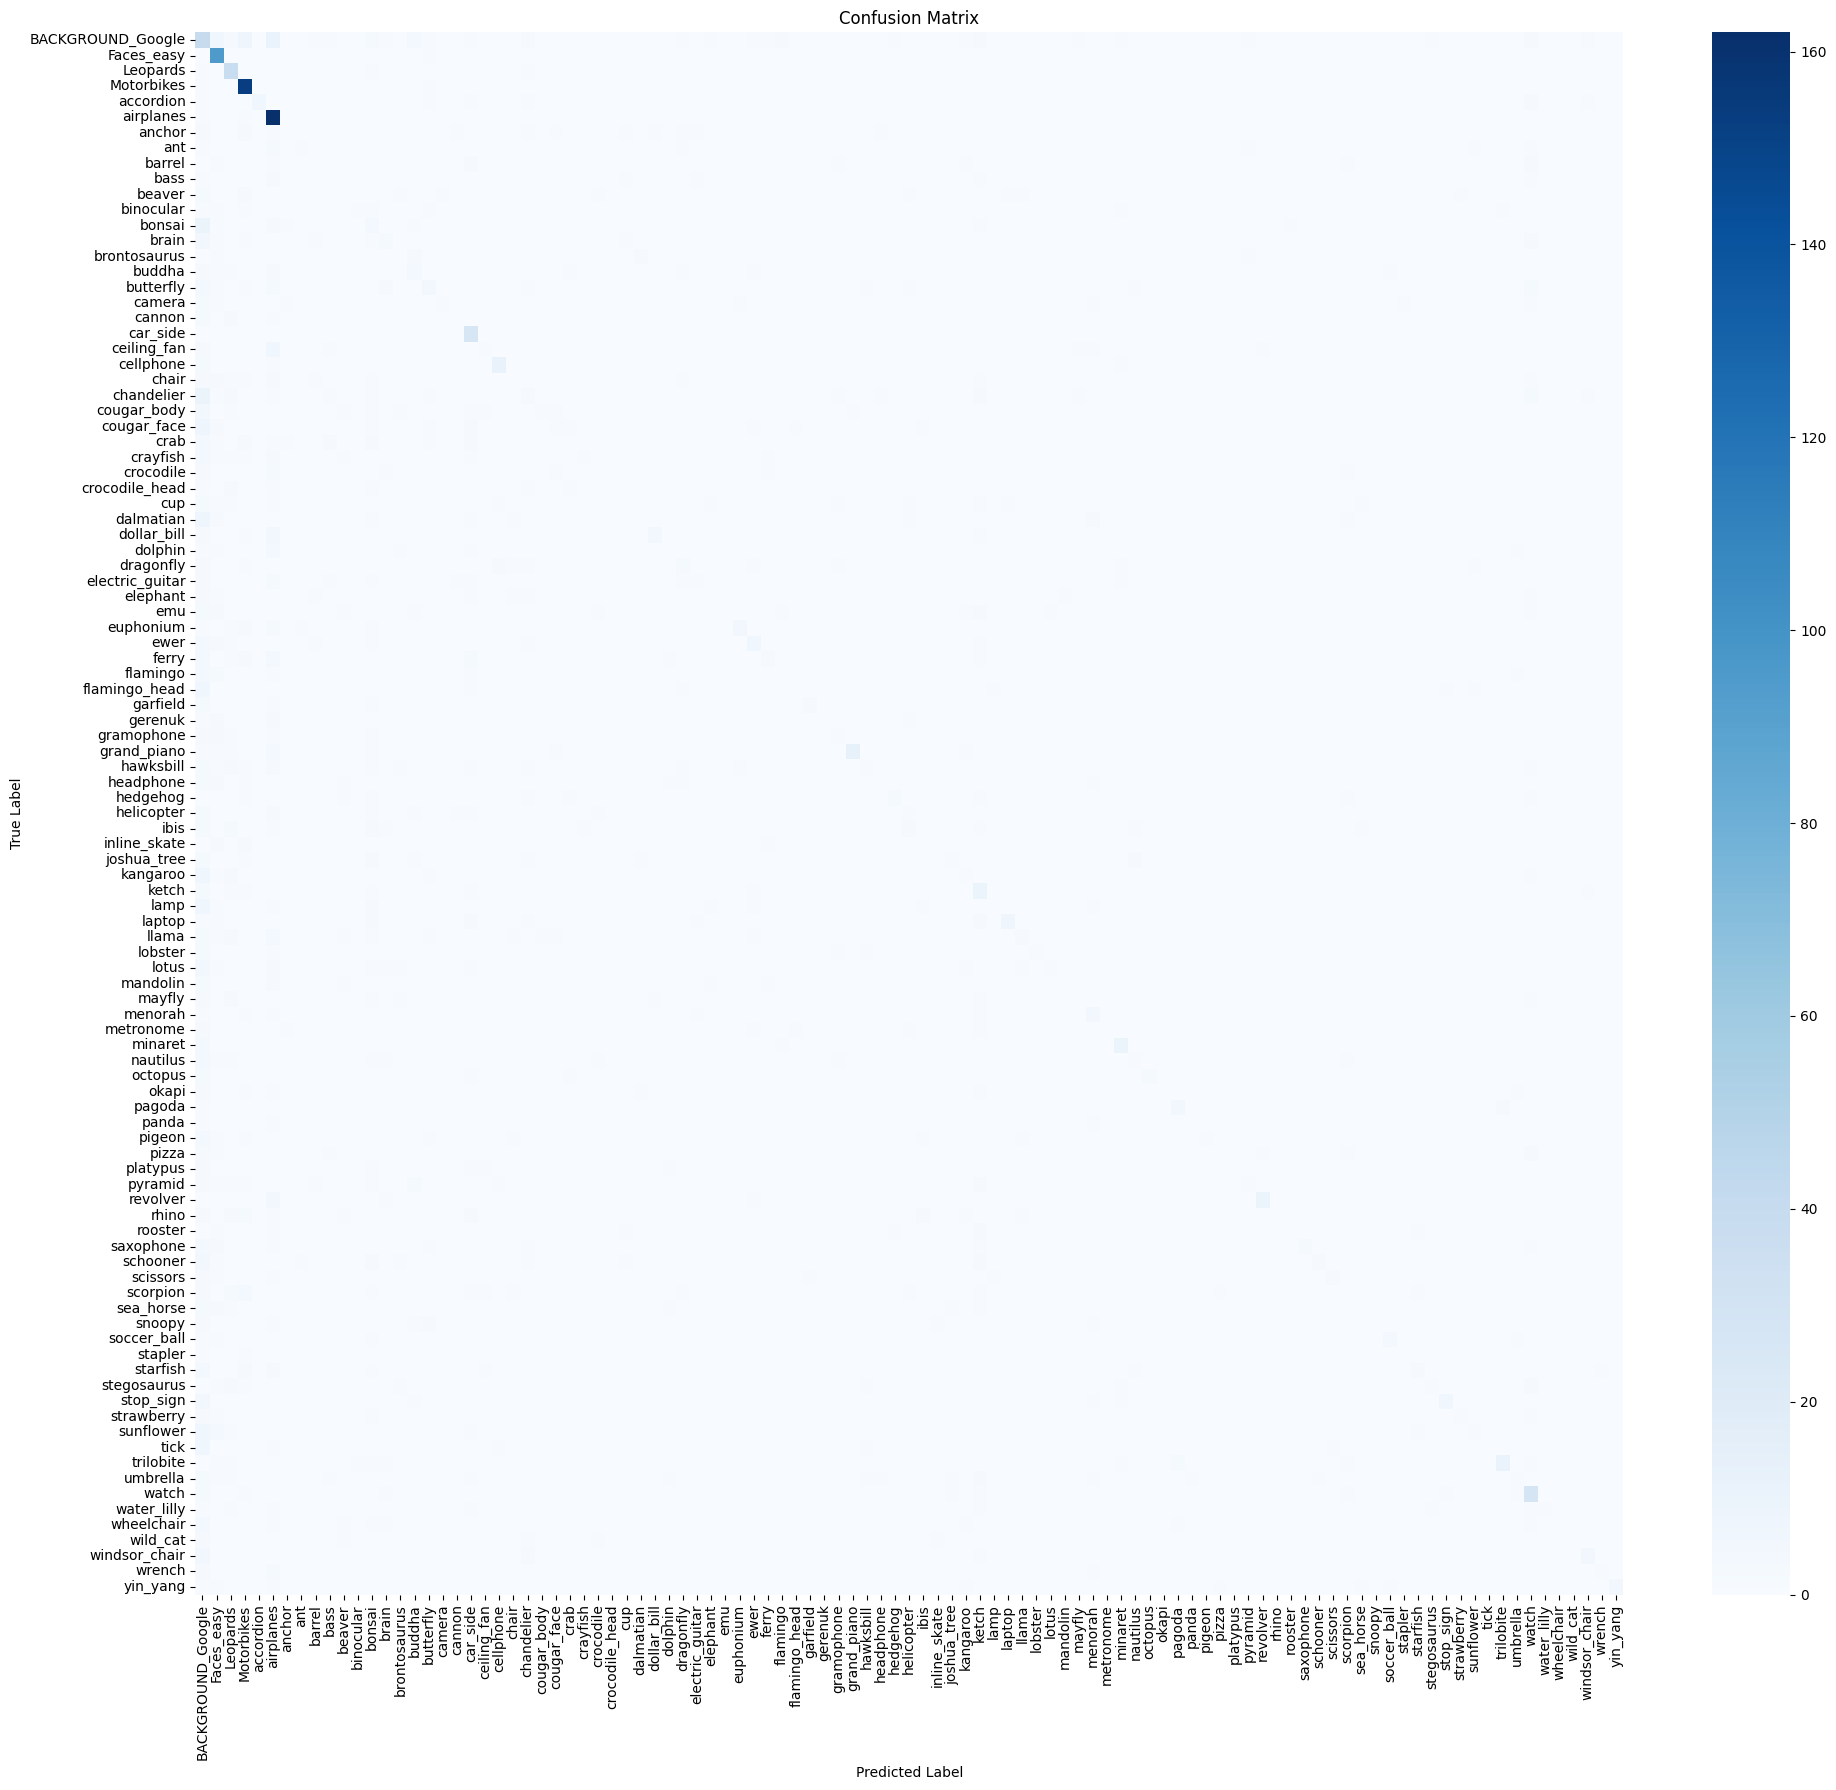

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure the model is in evaluation mode
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, raw_targets in test_loader:
        data = data.to(device)
        # Convert byte string targets to integer tensor targets
        target_indices = [class_to_idx[t.decode('utf-8')] for t in raw_targets]
        targets = torch.tensor(target_indices, dtype=torch.long).to(device)

        spk_rec, _ = model(data)

        # Sum spikes over time steps to get total spikes per class
        total_spikes_per_class = spk_rec.sum(dim=0) # [batch_size, num_classes]
        predicted_class_indices = torch.argmax(total_spikes_per_class, dim=1)

        all_preds.extend(predicted_class_indices.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

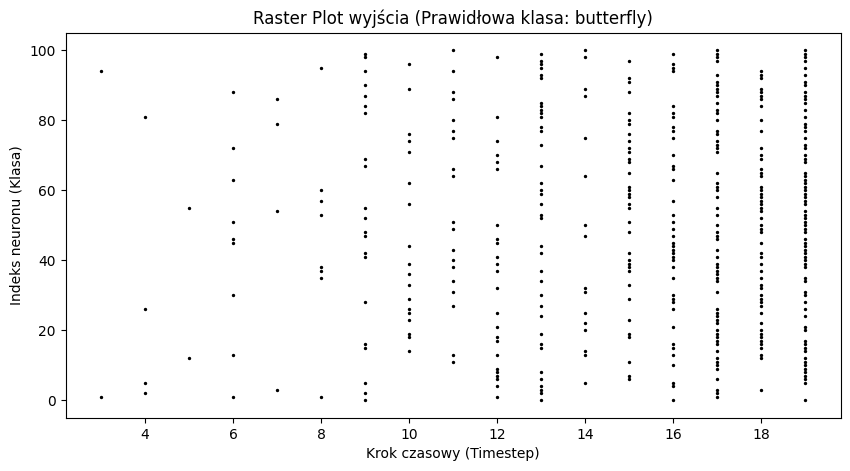

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
splt.raster(spk_sample, ax, s=2, c="black")

plt.title(
    f"Raster Plot wyjścia (Prawidłowa klasa: {class_names[target_sample]})"
)
plt.xlabel("Krok czasowy (Timestep)")
plt.ylabel("Indeks neuronu (Klasa)")
plt.show()

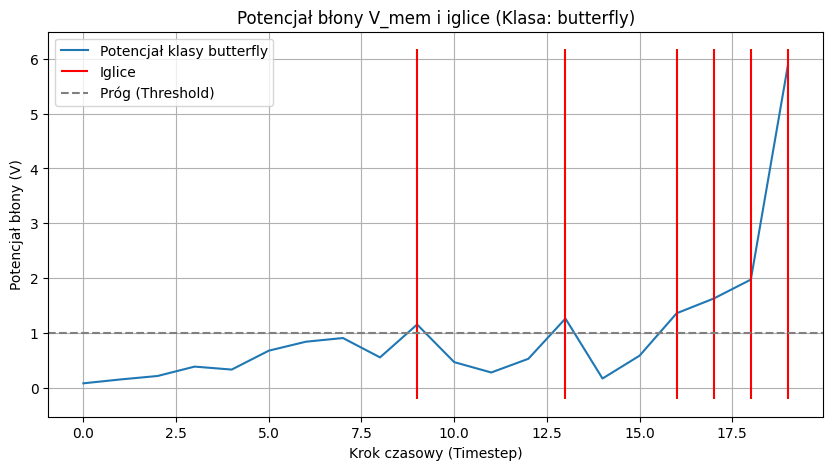

In [18]:
# Wizualizacja potencjału błony dla neuronu celowego za pomocą matplotlib
fig, ax = plt.subplots(figsize=(10, 5))

mem_trace = mem_sample[:, target_sample].cpu().numpy()
spike_trace = spk_sample[:, target_sample].cpu().numpy()

# Rysowanie potencjału błony
ax.plot(mem_trace, label=f'Potencjał klasy {class_names[target_sample]}', color='tab:blue')

# Rysowanie iglic jako linii pionowych
spike_times = np.where(spike_trace == 1)[0]
ax.vlines(spike_times, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], colors='red', linestyles='solid', label='Iglice')

# Dodanie linii progu
ax.axhline(y=1.0, color='grey', linestyle='--', label='Próg (Threshold)')

ax.set_title(f"Potencjał błony V_mem i iglice (Klasa: {class_names[target_sample]})")
ax.set_xlabel("Krok czasowy (Timestep)")
ax.set_ylabel("Potencjał błony (V)")
ax.legend()
ax.grid(True)
plt.show()

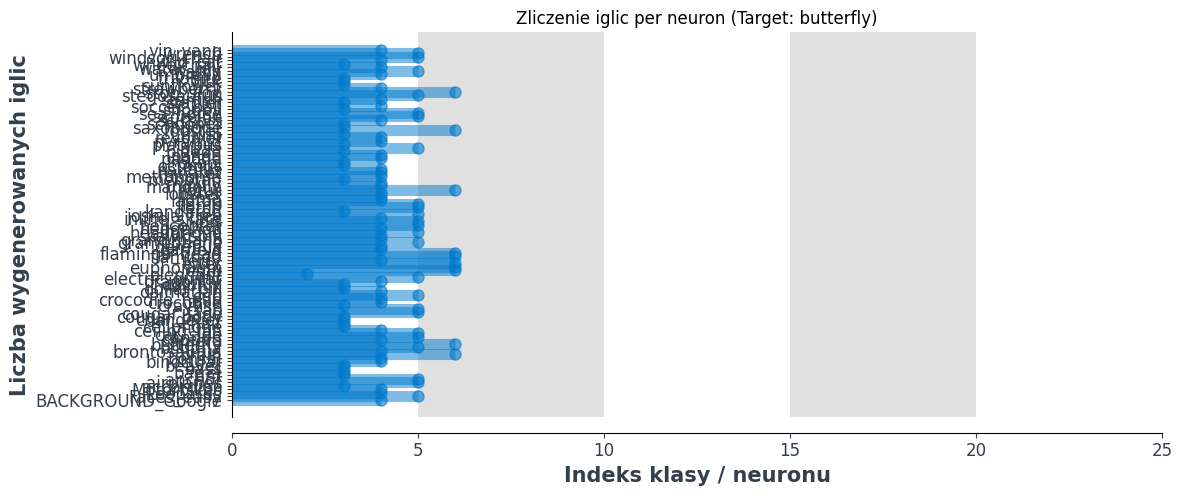

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
splt.spike_count(spk_sample, fig=fig, ax=ax, labels=class_names, num_steps=num_steps)

plt.title(
    f"Zliczenie iglic per neuron (Target: {class_names[target_sample]})"
)
plt.xlabel("Indeks klasy / neuronu")
plt.ylabel("Liczba wygenerowanych iglic")
plt.show()

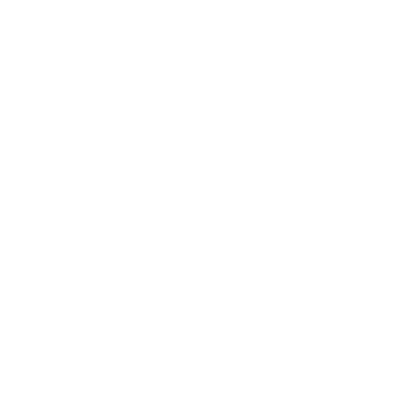

In [22]:
# data ma kształt [batch_size, num_steps, channels, height, width]
# Sumujemy po kanałach polaryzacji dla wybranej próbki: [num_steps, height, width]
input_events_2d = data[sample_idx].cpu().sum(dim=1)

fig, ax = plt.subplots(figsize=(5, 5))
anim = splt.animator(input_events_2d, fig, ax, interval=100)

# Wyświetlenie animacji w formacie HTML5 (Colab / Jupyter Notebook)
HTML(anim.to_jshtml())

#ZAPIS MODELU JAKO PLIK

In [23]:
torch.save(model.state_dict(), "scnn_model.pth")

#LOADING MODELU(kopiujcie do swojego kodu)


```
loaded_model = SCNNetwork().to(device)
loaded_model.load_state_dict(
    torch.load("scnn_model.pth", map_location=device)
)
```

